Student ID: 24166558

###DATA SET DOWNLOAD AND SETUP

Create a Kaggle Account to download HAM1000 dataset. Go to settings and create a token key. Use your username and token key here to download the dataset

Use Google Colab GPU-T4 for robust training speed

Create Hugging Face account and generate a token key. For the first time, authentication is required to use hugging face open source models.

Reference:
https://huggingface.co/google/vit-base-patch16-224

In [1]:
%%writefile kaggle.json
{
  "username": "",
  "key": ""
}


Writing kaggle.json


In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [3]:
!kaggle datasets list


ref                                                          title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
nalisha/job-salary-prediction-dataset                        Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000           3496         78                1  
ssssws/chocolate-sales-dataset-2023-2024                     Chocolate Sales Dataset 2023 - 2024                   24420255  2026-03-07 04:58:02.387000           6903        116                1  
grandmaster07/student-exam-performance-dataset-analysis      Student Exam Performance Dataset Analysis                96178  2026-02-10 09:47:13.350000          11193        191                1  
rhythmghai/food

In [4]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000


Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [05:12<00:00, 17.9MB/s]



In [5]:
!unzip skin-cancer-mnist-ham10000.zip #unzip the dataset here better to work in colab environment


Streaming output truncated to the last 5000 lines.
  inflating: ham10000_images_part_2/ISIC_0029325.jpg  
  inflating: ham10000_images_part_2/ISIC_0029326.jpg  
  inflating: ham10000_images_part_2/ISIC_0029327.jpg  
  inflating: ham10000_images_part_2/ISIC_0029328.jpg  
  inflating: ham10000_images_part_2/ISIC_0029329.jpg  
  inflating: ham10000_images_part_2/ISIC_0029330.jpg  
  inflating: ham10000_images_part_2/ISIC_0029331.jpg  
  inflating: ham10000_images_part_2/ISIC_0029332.jpg  
  inflating: ham10000_images_part_2/ISIC_0029333.jpg  
  inflating: ham10000_images_part_2/ISIC_0029334.jpg  
  inflating: ham10000_images_part_2/ISIC_0029335.jpg  
  inflating: ham10000_images_part_2/ISIC_0029336.jpg  
  inflating: ham10000_images_part_2/ISIC_0029337.jpg  
  inflating: ham10000_images_part_2/ISIC_0029338.jpg  
  inflating: ham10000_images_part_2/ISIC_0029339.jpg  
  inflating: ham10000_images_part_2/ISIC_0029340.jpg  
  inflating: ham10000_images_part_2/ISIC_0029341.jpg  
  inflating: h

In [6]:
#Import the necessary libraries
import torch
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoImageProcessor, ViTForImageClassification

from transformers import Trainer, TrainingArguments

from torchvision import transforms
from torch.utils.data import Dataset,DataLoader
from PIL import Image

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [7]:
#Get images-jpg files from the dataset folders
import os
import pandas as pd
def get_image_path(image_id):
    for folder in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
        path = os.path.join(folder, image_id + ".jpg")
        if os.path.exists(path):
            return path
    return None
df = pd.read_csv("HAM10000_metadata.csv")

In [8]:
df["path"] = df["image_id"].apply(get_image_path)
df = df.dropna(subset=["path"])


In [9]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,HAM10000_images_part_1/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,HAM10000_images_part_1/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,HAM10000_images_part_1/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,HAM10000_images_part_1/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,HAM10000_images_part_2/ISIC_0031633.jpg


In [10]:
#Encode class names to label numbers
label_map = {label: idx for idx, label in enumerate(df["dx"].unique())}
df["label"] = df["dx"].map(label_map)
df["label"] = df["label"].astype(int)


In [11]:
# Check unique labels
print(df["label"].unique())

# Drop invalid ones
df = df.dropna(subset=["label"])

# Force integer type
df["label"] = df["label"].astype(int)

[0 1 2 3 4 5 6]


The dataset contains 10,000 images that were split into training, validation and test datasets (80/10/10).

In [12]:
#Split the dataset into train, val and test
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42
)


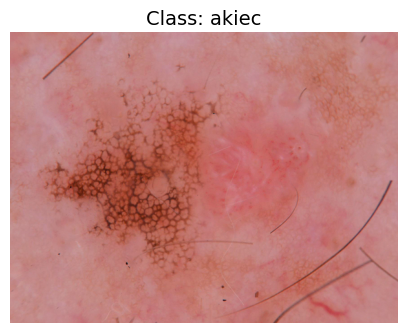

In [13]:
import matplotlib.pyplot as plt
from PIL import Image

def show_sample(df, idx):
    row = df.iloc[idx]
    img = Image.open(row["path"]).convert("RGB")
    label_name = row["dx"]

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(f"Class: {label_name}", fontsize=14)
    plt.axis("off")
    plt.show()

# Example
show_sample(train_df, 5)


### Preprocessing and Augmentation

This involves various transforms such as resizing all images to have the same dimensions, normalizing, and scaling the pixel values to a uniform range. We can also add augmentations to our images like random flips, rotations, and color jitters.


•	A Vision Transformer (ViT-Base 32) model pretrained on ImageNet-21k , a large – scale dataset containing 14 million images across 21,000 classes is chosen from open source – Hugging Face models

In [14]:
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch32-224-in21k")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [15]:
'''Data Augmentation and Preprocessing
Resize, Normalize, Horizontal Flips, Color jitter
'''
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])
#No Augmentations for val and test data
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

test_transform = val_transform


In [16]:
'''A Class instance for Dataset-easier to process and augment the data'''
from torch.utils.data import Dataset
from PIL import Image,ImageOps

class HAM10000Dataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"])

        # Fix EXIF rotation
        img = ImageOps.exif_transpose(img)

        # Force RGB (fix grayscale, RGBA, CMYK)
        img = img.convert("RGB")

        # Apply transforms
        img = self.transform(img)

        label = int(row["label"])

        return {"pixel_values": img, "labels": torch.tensor(label, dtype=torch.long)}



In [17]:
train_dataset = HAM10000Dataset(train_df, transform=train_transform)
val_dataset   = HAM10000Dataset(val_df,   transform=val_transform)
test_dataset  = HAM10000Dataset(test_df,  transform=test_transform)


# Class names and abbr

   "bkl",    Benign keratosis

   "nv",     Melanocytic nevi

   "df",     Dermatofibroma

   "mel",    Melanoma

   "vasc",   Vascular lesions

   "bcc",   Basal cell carcinoma

   "akiec"   Actinic keratoses


In [18]:

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

print()
print(train_df['dx'].value_counts())
print(val_df['dx'].value_counts())
print(test_df['dx'].value_counts())

Train samples: 8012
Validation samples: 1001
Test samples: 1002

dx
nv       5364
mel       890
bkl       879
bcc       411
akiec     262
vasc      114
df         92
Name: count, dtype: int64
dx
nv       670
mel      111
bkl      110
bcc       51
akiec     33
vasc      14
df        12
Name: count, dtype: int64
dx
nv       671
mel      112
bkl      110
bcc       52
akiec     32
vasc      14
df        11
Name: count, dtype: int64


In [19]:
idx_to_class = {v: k for k, v in label_map.items()}


### Model Training

•	Stage 1: Freeze the Vision Transformer and train only the head (head is replaced with a new 7 class output layer).
This allows the model to adapt pretrained features to the new task

•	Stage 2: Unfreeze the last few transformer blocks (e.g., Block 10–11–12 in ViT-B/32) and fine-tune them with a much smaller learning rate.



In [21]:
#Ignore the mismatch warning
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch32-224-in21k",
    num_labels=7,#no of classes =7
    ignore_mismatched_sizes=True,
    output_attentions=True
)

model.safetensors:   0%|          | 0.00/352M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch32-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
for i in range(10):
    sample = train_dataset[i]
    print(type(sample["labels"]), sample["labels"])

<class 'torch.Tensor'> tensor(5)
<class 'torch.Tensor'> tensor(1)
<class 'torch.Tensor'> tensor(1)
<class 'torch.Tensor'> tensor(1)
<class 'torch.Tensor'> tensor(1)
<class 'torch.Tensor'> tensor(6)
<class 'torch.Tensor'> tensor(1)
<class 'torch.Tensor'> tensor(1)
<class 'torch.Tensor'> tensor(1)
<class 'torch.Tensor'> tensor(1)


In [ ]:
#Stage 1
for name,p in model.named_parameters():
    if not name.startswith('classifier'):
        p.requires_grad = False

In [ ]:
num_params = sum([p.numel() for p in model.parameters()])
trainable_params = sum([p.numel() for p in model.parameters() if p.requires_grad])

print(f"{num_params = :,} | {trainable_params = :,}")

num_params = 87,460,615 | trainable_params = 5,383


In [ ]:
from transformers import EarlyStoppingCallback

callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]

In [ ]:
training_args = TrainingArguments(
    output_dir="./vit-dermamnist",
    per_device_train_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    num_train_epochs=15,
    learning_rate=1e-4,
    weight_decay=1e-4,
    lr_scheduler_type="reduce_lr_on_plateau",
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to="tensorboard",
    load_best_model_at_end=True,
    logging_strategy="epoch",

)

In [26]:
# Used to load samples with given batch size -32 (Data Loaders)
def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.tensor(
        [int(item["labels"]) for item in batch],  # FORCE scalar
        dtype=torch.long
    )
    return {"pixel_values": pixel_values, "labels": labels}


In [ ]:
batch = [train_dataset[i] for i in range(4)]
collate_fn(batch)

{'pixel_values': tensor([[[[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           ...,
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000]],
 
          [[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           ...,
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000]],
 
          [[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000

In [ ]:
#Metrics computation
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def compute_metrics(eval_pred):
    preds = eval_pred.predictions
    labels = eval_pred.label_ids

    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.argmax(preds, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

###Stage 1 - Freezing all layers

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    callbacks=callbacks
)




In [ ]:
sample = train_dataset[0]
print(type(sample["pixel_values"]))
print(sample["pixel_values"].shape)

print(sample["labels"], type(sample["labels"]))

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
tensor(5) <class 'torch.Tensor'>


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.890196,0.923492,0.675325,0.140819
2,0.855049,0.894271,0.686314,0.175090
3,0.828421,0.868695,0.698302,0.209117
4,0.805908,0.846465,0.705295,0.229962
5,0.787782,0.835153,0.718282,0.286257
6,0.770355,0.820355,0.724276,0.314035
7,0.759438,0.806420,0.725275,0.317554
8,0.745303,0.795422,0.731269,0.326477
9,0.732900,0.783365,0.731269,0.324400
10,0.723225,0.773195,0.737263,0.335349


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3765, training_loss=0.7605874759425838, metrics={'train_runtime': 1975.6744, 'train_samples_per_second': 60.83, 'train_steps_per_second': 1.906, 'total_flos': 9.493213940569498e+18, 'train_loss': 0.7605874759425838, 'epoch': 15.0})

###Stage 2 - Unfreezing last three layers and Fine tuning

In [ ]:
for param in model.vit.encoder.layer[-3:].parameters():
    param.requires_grad = True

In [ ]:
training_args_stage2 = TrainingArguments(
    output_dir="./vit_stage2",
    per_device_train_batch_size=32,
    num_train_epochs=20,
    learning_rate=5e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="tensorboard",
    logging_strategy="epoch",
)


In [ ]:
#Stage 2
trainer_2 = Trainer(
    model=model,
    args=training_args_stage2,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    callbacks=callbacks
)

In [ ]:
trainer_2.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.587477,0.517025,0.835165,0.681656
2,0.469241,0.494327,0.834166,0.687848
3,0.394784,0.468077,0.841159,0.711719
4,0.330323,0.453939,0.848152,0.722755
5,0.267523,0.455212,0.846154,0.717003
6,0.223850,0.467776,0.825175,0.733932
7,0.183105,0.433366,0.865135,0.750983
8,0.151498,0.434024,0.852148,0.747044
9,0.120648,0.475011,0.859141,0.745837
10,0.095524,0.448526,0.862138,0.765648


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2510, training_loss=0.28239725804423904, metrics={'train_runtime': 1449.9081, 'train_samples_per_second': 110.517, 'train_steps_per_second': 3.462, 'total_flos': 6.328809293712998e+18, 'train_loss': 0.28239725804423904, 'epoch': 10.0})

The classifier head alone learns some signal, but struggles with class balance and complex features.
Fine-tuning enables the model to adapt learned representations to domain-specific patterns
While accuracy stabilizes, macro F1 continues improving, indicating better performance on underrepresented classes.”

###Predictions
Save the trained model and processor. Easy to use later even if GPU runtime has stopped

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
vit_model = ViTForImageClassification.from_pretrained("/content/drive/MyDrive/vit-ham10000",attn_implementation='eager')
vit_processor = AutoImageProcessor.from_pretrained("/content/drive/MyDrive/vit-ham10000")



Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [27]:
trainer_vit = Trainer(
    model=vit_model,
    data_collator=collate_fn
)

In [28]:
from sklearn.metrics import confusion_matrix
import numpy as np

preds = trainer_vit.predict(test_dataset)

logits = preds.predictions
if isinstance(logits, tuple):
    logits = logits[0]

y_pred = np.argmax(logits, axis=1)
y_true = preds.label_ids


In [29]:
print(np.unique(y_true, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6]), array([110, 671,  11, 112,  14,  52,  32]))


In [33]:
#class names order as per y_true
class_names=[
    'bkl','nv','df','mel','vasc','bcc','akiec'
]

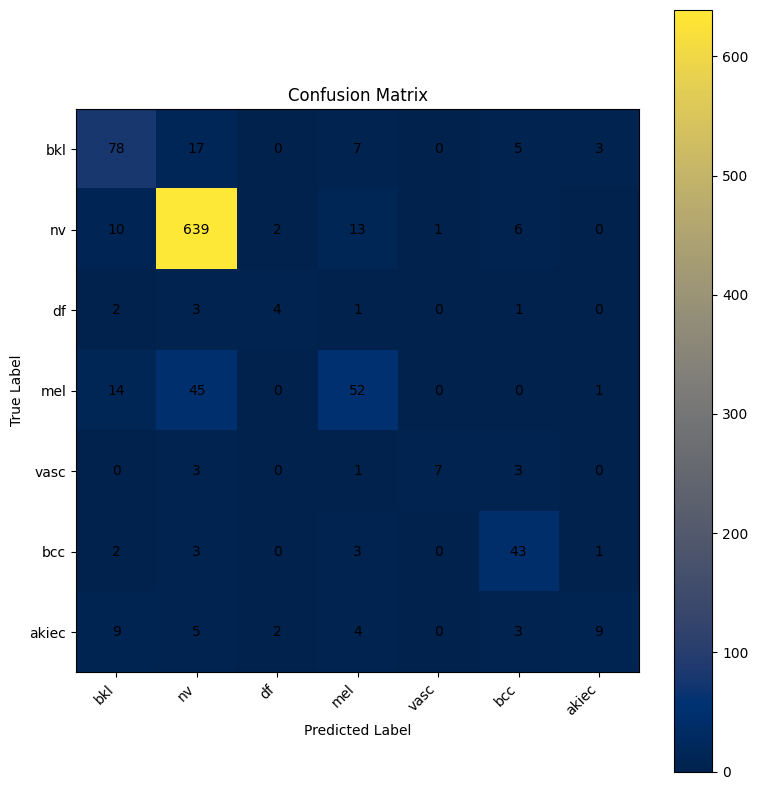

In [34]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))
im = plt.imshow(cm, cmap="cividis")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

                      precision    recall  f1-score   support

   Actinic keratoses       0.68      0.71      0.69       110
Basal cell carcinoma       0.89      0.95      0.92       671
    Benign keratosis       0.50      0.36      0.42        11
      Dermatofibroma       0.64      0.46      0.54       112
            Melanoma       0.88      0.50      0.64        14
    Melanocytic nevi       0.70      0.83      0.76        52
    Vascular lesions       0.64      0.28      0.39        32

            accuracy                           0.83      1002
           macro avg       0.71      0.59      0.62      1002
        weighted avg       0.82      0.83      0.82      1002



The classification report highlights a clear imbalance in model performance across classes. This is reflected in the gap between accuracy (0.83) and macro F1 score (0.62). These results demonstrate the sensitivity of Vision Transformers to dataset size and class imbalance, as well as the inherent difficulty of distinguishing visually similar dermatological conditions.

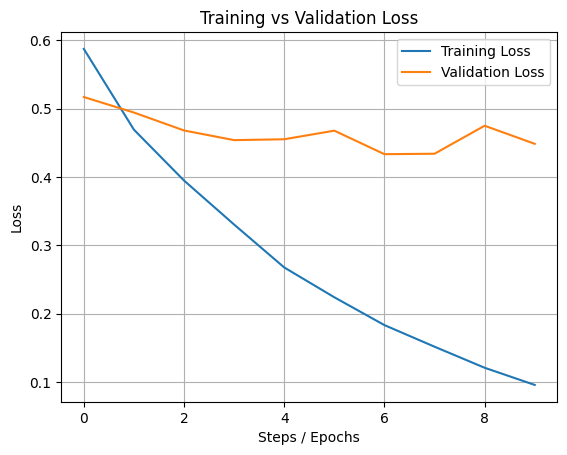

In [ ]:
import pandas as pd

logs = pd.read_csv("training_logs_2.csv")

# Extract values safely
train_loss = logs["loss"].dropna().values
eval_loss = logs["eval_loss"].dropna().values

plt.figure()

plt.plot(train_loss, label="Training Loss")
plt.plot(eval_loss, label="Validation Loss")

plt.xlabel("Steps / Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

The training loss decreases steadily, while validation loss stabilizes after initial improvement. A divergence between training and validation loss suggests mild overfitting, which is expected when fine-tuning large models on moderately sized datasets. However, performance metrics such as accuracy and macro F1 continue to improve, indicating that generalization remains strong.

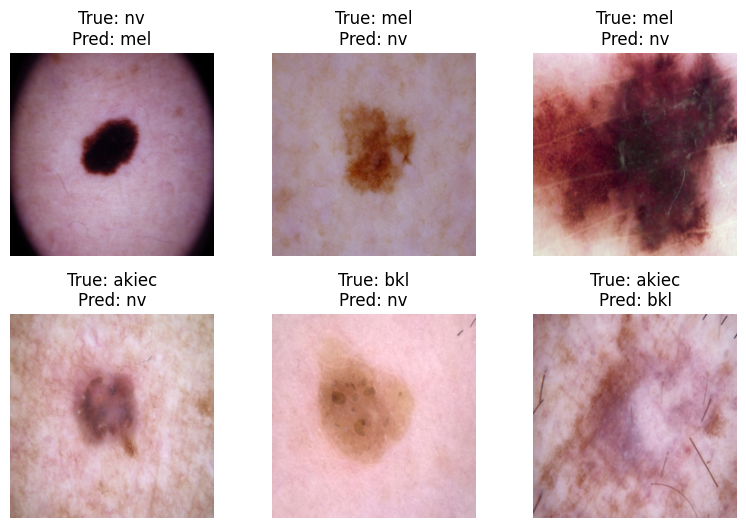

In [35]:
mis_idx = np.where(y_pred != y_true)[0]

plt.figure(figsize=(8, 8))

for i, idx in enumerate(mis_idx[:6]):
    sample = test_dataset[idx]
    img = sample["pixel_values"].permute(1, 2, 0).numpy()

    # unnormalize
    img = (img * vit_processor.image_std) + vit_processor.image_mean
    img = np.clip(img, 0, 1)

    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

###Attention Maps
Yellow: high attention (lesion region), blue: background skin region.

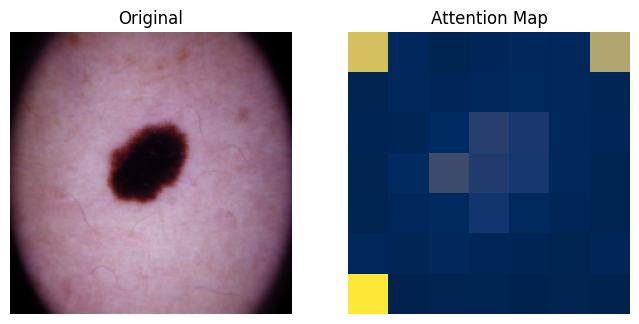

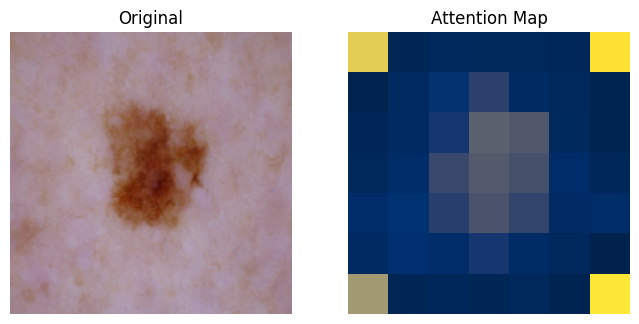

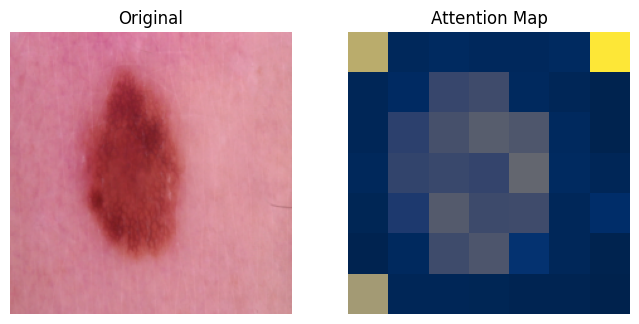

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit_model.to(device)
vit_model.eval()

# IMPORTANT
vit_model.config.output_attentions = True

def show_attention(idx):
    sample = test_dataset[idx]

    # MOVE input to SAME device as model
    pixel_values = sample["pixel_values"].unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = vit_model(pixel_values, output_attentions=True)

    attentions = outputs.attentions[-1]  # last layer
    attn = attentions.mean(dim=1)[0]     # average heads

    cls_attn = attn[0, 1:]

    size = int(cls_attn.shape[0] ** 0.5)
    attn_map = cls_attn.reshape(size, size).cpu().numpy()

    # original image
    img = sample["pixel_values"].permute(1, 2, 0).cpu().numpy()
    img = (img * processor.image_std) + processor.image_mean
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(attn_map, cmap="cividis")  # accessible colormap
    plt.title("Attention Map")
    plt.axis("off")

    plt.show()

# show few examples
for i in range(3):
    show_attention(i)

The attention map highlights regions of the image that contribute most to the model’s prediction. As shown, the Vision Transformer focuses on the lesion area, demonstrating its ability to identify relevant spatial features. The coarse structure of the attention map reflects the patch-based representation used by the model, where each token corresponds to a fixed image region.

### Save the model

In [ ]:
inputs = vit_processor()

In [ ]:
trainer_2.save_model("vit-ham10000")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
processor.save_pretrained("vit-ham10000")

['vit-ham10000/preprocessor_config.json']

In [ ]:
import pandas as pd

logs = pd.DataFrame(trainer.state.log_history)
logs.to_csv("training_logs_1.csv", index=False)

In [ ]:
logs = pd.DataFrame(trainer_2.state.log_history)
logs.to_csv("training_logs_2.csv", index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
trainer_2.save_model("/content/drive/MyDrive/vit-ham10000")
processor.save_pretrained("/content/drive/MyDrive/vit-ham10000")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['/content/drive/MyDrive/vit-ham10000/preprocessor_config.json']